# UV-Vis Spectroscopy of Everyday Fluorophores — Session 01 (pilot)

Session 01 is a **scattershot pilot run** across three instruments (Shimadzu UV-2550, Horiba FluoroMax-3, PerkinElmer Lambda 750). This notebook sets up the data → report pipeline so a comprehensive Session 02 can reuse it end-to-end.

Kept from this pilot:

- UV-2550: five of six samples (quinine scan was corrupted).
- FluoroMax-3: one fully labeled emission + excitation pair (yellow highlighter).
- Lambda 750: not yet run.

## 1. Load and inspect data

Files are read from GitHub raw URLs (Colab-compatible), with a fallback to local relative paths when the notebook runs before a push.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.error import HTTPError, URLError
from scipy.signal import find_peaks

BASE_URL = ('https://raw.githubusercontent.com/vivianweidai/science/main/'
            'research/projects/20260420%20UV-Vis%20Spectroscopy')
LOCAL = Path('..')

def _read(subdir, name, skiprows, columns):
    try:
        df = pd.read_csv(f'{BASE_URL}/{subdir}/{name}',
                         skiprows=skiprows, header=None, names=columns)
    except (HTTPError, URLError):
        df = pd.read_csv(LOCAL / subdir / name,
                         skiprows=skiprows, header=None, names=columns)
    return df.dropna().astype(float).reset_index(drop=True)

def load_uvvis(name):
    return _read('data/one', name, 2, ['wavelength_nm', 'absorbance'])

def load_fluoromax(name):
    return _read('data/two', name, 2, ['wavelength_nm', 'signal'])

uvvis = {
    'S2 yellow HL (neat)':       load_uvvis('20260420_UVVis_S2_yellow_rep1.txt'),
    'S2 yellow HL (1 drop/3mL)': load_uvvis('20260420_UVVis_S2_yellow_1drop.txt'),
    'S3 pink HL':                load_uvvis('20260420_UVVis_S3_pink.txt'),
    'S4 curcumin (EtOH)':        load_uvvis('20260420_UVVis_S4_curcumin.txt'),
    'S5 green tea (EtOH)':       load_uvvis('20260420_UVVis_S5_greentea.txt'),
    'S6 salicylate':             load_uvvis('20260420_UVVis_S6_salicylate.txt'),
}

for label, df in uvvis.items():
    sat = (df.absorbance >= 4.9).sum()
    print(f'{label:32s}  {len(df):5d} points  '
          f'{df.wavelength_nm.min():.0f}-{df.wavelength_nm.max():.0f} nm  '
          f'A_max={df.absorbance.max():.2f}  saturated_points={sat}')

S2 yellow HL (neat)                1221 points  190-800 nm  A_max=0.89  saturated_points=0
S2 yellow HL (1 drop/3mL)          1201 points  200-800 nm  A_max=5.00  saturated_points=41
S3 pink HL                         1201 points  200-800 nm  A_max=5.00  saturated_points=14
S4 curcumin (EtOH)                 1221 points  190-800 nm  A_max=5.00  saturated_points=8
S5 green tea (EtOH)                1221 points  190-800 nm  A_max=5.00  saturated_points=23
S6 salicylate                      1221 points  190-800 nm  A_max=5.00  saturated_points=51


The S3 pink, S5 green tea, and S6 salicylate stocks saturate the detector (A pinned at 5.0) across parts of the UV. These samples need dilution before Session 02 — surfacing this is exactly the purpose of the pilot.

## 2. UV-Vis absorption overlay

One trace per sample, 200–750 nm. The primary peak in each sample's expected window is auto-annotated; saturated points (A ≥ 4.9) are skipped by the peak picker.

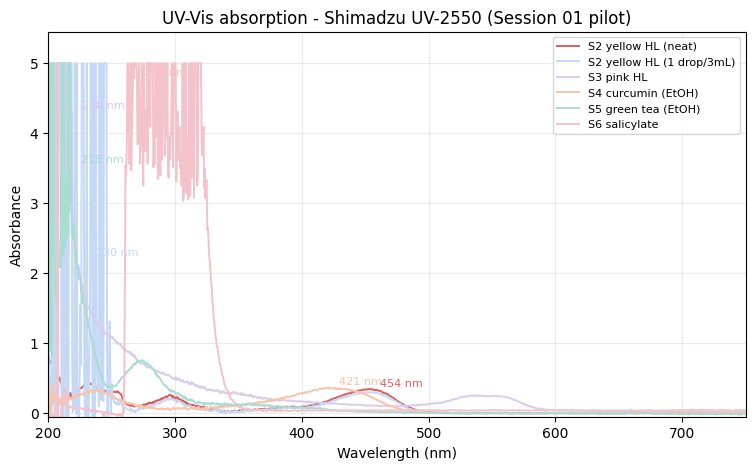

,sample,lambda_max_nm,A_at_peak
0,S2 yellow HL (neat),453.5,0.346
1,S2 yellow HL (1 drop/3mL),230.0,2.216
2,S3 pink HL,218.5,4.312
3,S4 curcumin (EtOH),421.0,0.365
4,S5 green tea (EtOH),218.0,3.539
5,S6 salicylate,267.5,4.786


In [2]:
PALETTE = ['#d95f5f', '#c5d9f7', '#d9ccee', '#f9c4a8', '#a8ddd4', '#f4c2cb']
SEARCH_WINDOW = {
    'S2 yellow HL (neat)':       (200, 600),
    'S2 yellow HL (1 drop/3mL)': (200, 600),
    'S3 pink HL':                (200, 700),
    'S4 curcumin (EtOH)':        (210, 600),
    'S5 green tea (EtOH)':       (210, 750),
    'S6 salicylate':             (210, 500),
}

def primary_peak(df, lo, hi):
    sub = df[(df.wavelength_nm >= lo) & (df.wavelength_nm <= hi) &
             (df.absorbance < 4.9)].reset_index(drop=True)
    if sub.empty:
        return None, None
    peaks, props = find_peaks(sub.absorbance.values, prominence=0.02, distance=20)
    if not len(peaks):
        i = sub.absorbance.idxmax()
        return float(sub.wavelength_nm.iloc[i]), float(sub.absorbance.iloc[i])
    idx = peaks[np.argmax(props['prominences'])]
    return float(sub.wavelength_nm.iloc[idx]), float(sub.absorbance.iloc[idx])

fig, ax = plt.subplots(figsize=(9, 5))
rows = []
for (label, df), color in zip(uvvis.items(), PALETTE):
    ax.plot(df.wavelength_nm, df.absorbance, color=color, lw=1.4, label=label)
    lo, hi = SEARCH_WINDOW[label]
    peak_nm, peak_a = primary_peak(df, lo, hi)
    rows.append({'sample': label, 'lambda_max_nm': peak_nm, 'A_at_peak': peak_a})
    if peak_nm is not None:
        ax.annotate(f'{peak_nm:.0f} nm', xy=(peak_nm, peak_a),
                    xytext=(peak_nm + 8, peak_a + 0.04),
                    fontsize=8, color=color)
ax.set_xlim(200, 750)
ax.set_ylim(-0.05, None)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance')
ax.set_title('UV-Vis absorption - Shimadzu UV-2550 (Session 01 pilot)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.25)
plt.show()

peaks_df = pd.DataFrame(rows)
peaks_df

## 3. FluoroMax dilution table (Beer-Lambert handoff)

Guide (Doc 1 Part F): dilute each stock by **D = A_measured / 0.05** before the FluoroMax session so A at λ_ex stays below 0.1 and avoids the inner-filter effect. Stocks with A > 1.5 are flagged — their measured peaks are unreliable and they must be diluted before being rescanned.

In [3]:
dilution = peaks_df.copy()
dilution['D = A / 0.05'] = (dilution['A_at_peak'] / 0.05).round(1)
dilution['flag'] = np.where(dilution['A_at_peak'] > 1.5,
                            'too concentrated - dilute before rescan', '')
dilution

,sample,lambda_max_nm,A_at_peak,D = A / 0.05,flag
0,S2 yellow HL (neat),453.5,0.346,6.9,
1,S2 yellow HL (1 drop/3mL),230.0,2.216,44.3,too concentrated - dilute before rescan
2,S3 pink HL,218.5,4.312,86.2,too concentrated - dilute before rescan
3,S4 curcumin (EtOH),421.0,0.365,7.3,
4,S5 green tea (EtOH),218.0,3.539,70.8,too concentrated - dilute before rescan
5,S6 salicylate,267.5,4.786,95.7,too concentrated - dilute before rescan


## 4. Fluorescence fingerprint — yellow highlighter

Only yellow HL has a labeled emission + excitation pair in the pilot data. Emission (S1) is in counts-per-second and excitation (R1) is in microamps (reference detector), so both are normalized to 0–1 for overlay.

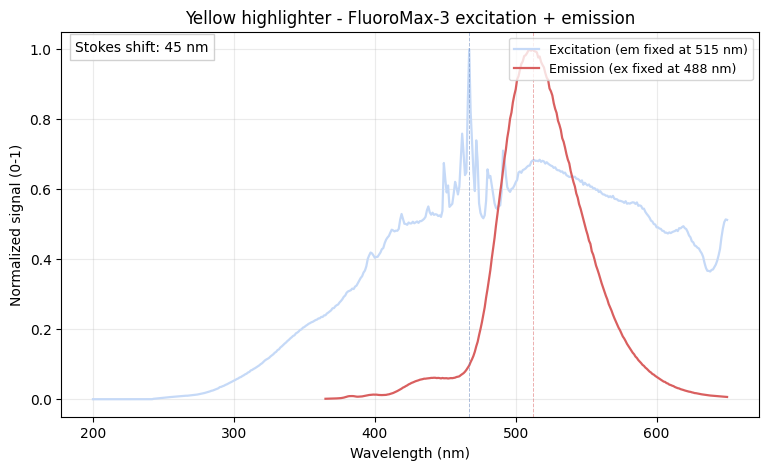

ex peak: 467 nm   em peak: 512 nm   Stokes shift: 45 nm


In [4]:
em = load_fluoromax('20260420_S2_yellow_EM_ex488.csv')
ex = load_fluoromax('20260420_S2_yellow_EX_em515.csv')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ex.wavelength_nm, ex.signal / ex.signal.max(),
        color='#c5d9f7', lw=1.6, label='Excitation (em fixed at 515 nm)')
ax.plot(em.wavelength_nm, em.signal / em.signal.max(),
        color='#d95f5f', lw=1.6, label='Emission (ex fixed at 488 nm)')

em_peak = em.loc[em.signal.idxmax(), 'wavelength_nm']
ex_peak = ex.loc[ex.signal.idxmax(), 'wavelength_nm']
stokes = em_peak - ex_peak

ax.axvline(em_peak, color='#d95f5f', lw=0.7, ls='--', alpha=0.5)
ax.axvline(ex_peak, color='#5d7fb8', lw=0.7, ls='--', alpha=0.5)
ax.text(0.02, 0.95, f'Stokes shift: {stokes:.0f} nm',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(facecolor='white', edgecolor='#cccccc', alpha=0.9))
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Normalized signal (0-1)')
ax.set_title('Yellow highlighter - FluoroMax-3 excitation + emission')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.25)
plt.show()

print(f'ex peak: {ex_peak:.0f} nm   em peak: {em_peak:.0f} nm   '
      f'Stokes shift: {stokes:.0f} nm')

## 5. Pilot conclusions and Session 02 plan

**What worked**
- Curcumin UV-Vis peak at 421 nm matches literature (expected 425 nm).
- Yellow HL fluorescence fingerprint resolved: ~467 nm excitation, ~512 nm emission, ~45 nm Stokes shift.
- Data → figure pipeline runs end-to-end in one notebook, Colab-compatible.

**What did not**
- Quinine UV-Vis scan corrupted (class-demo data leaked in); quinine is absent from the pilot.
- Pink, green tea, and salicylate stocks saturated the detector in the UV — stocks must be diluted before Session 02.
- Most FluoroMax CSVs in the raw dump were unlabeled Origin workbook shells; only the yellow pair could be matched back to a sample.

**Session 02 plan**
- Rerun all six UV-2550 scans; predilute any stock with A > 1.5.
- Rerun FluoroMax-3 with the file-naming convention from Doc 2 (`YYYYMMDD_S{n}_{sample}_{EM|EX}_{ex|em}{λ}.csv`) so every file is self-identifying.
- Add the Lambda 750 session (cross-validation 200–800 nm + NIR 800–2500 nm on both blanks).
- Re-run this notebook against the Session 02 data — the pipeline is already wired.

---

<a href="https://colab.research.google.com/github/vivianweidai/science/blob/main/research/projects/20260420%20UV-Vis%20Spectroscopy/output/uv_spectroscopy.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align:middle;"></a>